# Revised and In-Progress with Code Enhancements

In [ ]:
# Import necessary libraries for date and time manipulation, timezone handling, and displaying formatted text in a notebook
from datetime import datetime
from pytz import timezone
from IPython.display import display, Markdown, HTML

# Track the time when the first cell is executed
first_cell_time = datetime.now()

# Set IST timezone (Indian Standard Time)
ist = timezone('Asia/Kolkata')

# Get the current time in IST for the first cell entry
current_time_ist_first = datetime.now(ist).strftime('%Y-%m-%d %H:%M:%S')

# Display the statement "This is the first cell" in green and bold
display(HTML("<p style='color:green; font-weight:bold;'>This is the first cell. Initialization and setup are done below:</p>"))

# Display the current IST time for the first cell in bold (default color)
display(Markdown(f'**First Cell Entry Time: {current_time_ist_first}**'))


**First Cell Entry Time: 2025-01-13 16:44:19**

In [ ]:
# Importing the necessary libraries
import pandas as pd  # Pandas for data manipulation and analysis
import matplotlib.pyplot as plt  # Matplotlib for data visualization, including plotting charts
from sklearn.linear_model import LinearRegression  # Linear Regression model for machine learning
import pickle  # Pickle for serializing and deserializing Python objects, used for saving/loading machine learning models

In [ ]:
# Reading a CSV file from a URL and creating a DataFrame
df = pd.read_csv('https://raw.githubusercontent.com/9394113857/Data-Sets/a7ba0b540a02e3a0e06564365c9fd8730a60d382/house_price.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Area    10 non-null     int64
 1   Price   10 non-null     int64
dtypes: int64(2)
memory usage: 288.0 bytes


In [ ]:
df.shape

(10, 2)

In [ ]:
# Displaying the DataFrame
df

,Area,Price
0,1000,1500000
1,1200,1800000
2,1500,2250000
3,1800,2700000
4,2000,3000000
5,2300,3450000
6,2500,3750000
7,2700,4050000
8,3000,4500000
9,3200,4800000


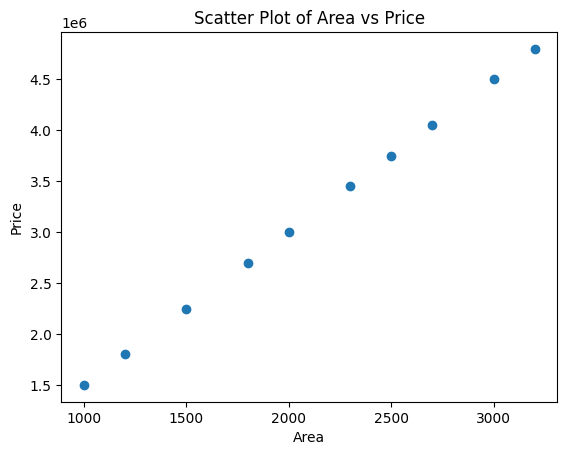

In [ ]:
# Creating a scatter plot to visualize the relationship between 'Area' and 'Price'
plt.scatter(df['Area'], df['Price'])
plt.xlabel('Area')  # Adding label to the x-axis
plt.ylabel('Price')  # Adding label to the y-axis
plt.title('Scatter Plot of Area vs Price')  # Adding a title to the plot
plt.show()  # Displaying the plot

In [ ]:
# Extracting the 'Area' column values and reshaping it into a 2D array with a single column
# The -1 in the reshape function is a placeholder that automatically calculates the size of the other dimension,
# ensuring that the resulting array has the same number of elements as the original
x = df['Area'].values.reshape(-1, 1)

# Extracting the 'Price' column values and reshaping it into a 2D array with a single column
y = df['Price'].values.reshape(-1, 1)

In [ ]:
# Create a Linear Regression model instance
lin = LinearRegression()

# Fit the model using feature 'x' and target 'y' data
lin.fit(x, y)

LinearRegression()

In [ ]:
# Save the trained Linear Regression model using Pickle
import pickle

# Specify the filename ('house_price_linear_regression.pkl') and open in binary write mode ('wb')
pickle.dump(lin, open('house_price_linear_regression.pkl', 'wb'))

In [ ]:
# Load the saved Linear Regression model using Pickle
import pickle

# Specify the filename ('house_price_linear_regression.pkl') and open in binary read mode ('rb')
loaded_linear_regression_model = pickle.load(open("house_price_linear_regression.pkl", "rb"))

In [ ]:
import pickle
from rich.console import Console
import time  # Import the time module to check execution time
from datetime import datetime  # Import datetime module for current date and time
import warnings
import sys

# Suppress the specific warning related to feature names
warnings.filterwarnings("ignore", message=".*does not have valid feature names.*")

# Record the start time
start_time = time.time()

# Get the current date and time at the start
start_datetime = datetime.now().strftime("%Y-%m-%d %H:%M:%S")  # Format: Year-Month-Day Hour:Minute:Second

# Load the pre-trained linear regression model
loaded_linear_regression_model = pickle.load(open('house_price_linear_regression.pkl', 'rb'))  # Replace with the actual path to your model file

# Create a Console instance for rich text printing
console = Console()

# Print the start date and time
console.print(f"[bold cyan]Execution Started at: {start_datetime}[/bold cyan]")

# Show the current date and time right before asking for the user input
current_datetime_before_input = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
console.print(f"[bold cyan]Current Date and Time before input: {current_datetime_before_input}[/bold cyan]")

# Get user input for area with a colorized prompt
console.print("[bold cyan]Please Enter Area in Sq ft (Press Enter for default 900 sq ft):[/bold cyan]", end=" ")

area_input = input()

# Check if the user input is empty (i.e., they just pressed Enter)
if area_input == "":
    area = 900  # Use 900 sq ft as the default value if no input is provided
    console.print("[bold yellow]No area entered, using default: 900 sq ft[/bold yellow]")
else:
    # If the user provided an area, convert it to a float
    try:
        area = float(area_input)
        console.print(f"[bold green]User entered area: {area} sq ft[/bold green]")
    except ValueError:
        console.print("[bold red]Invalid input! Please enter a valid number for area.[/bold red]")
        exit()

# Live update feature: Update the current time in real-time as the program runs
for _ in range(5):  # Loop for 5 seconds, update the current time every second
    time.sleep(1)  # Delay for 1 second
    live_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    console.print(f"[bold cyan]Live current time: {live_time}[/bold cyan]", end="\r")
    sys.stdout.flush()  # This ensures the line gets updated, not appended

# Use the model to predict based on the entered or defaulted area
prediction_value = loaded_linear_regression_model.predict([[area]])

# Extract the predicted price from the array (it should be a single value) using .item()
predicted_price = prediction_value[0].item()  # Using .item() to convert the NumPy array to a scalar

# Print the entered or defaulted area in bold magenta
console.print(f"[bold magenta]The entered area: {area} Sq ft[/bold magenta]")

# Print the predicted value from the model in bold blue, formatted properly
console.print(f"[bold blue]The Price Amount is: {predicted_price:,.2f} Rupees[/bold blue]")

# Record the end time and calculate the total time taken
end_time = time.time()
execution_time = end_time - start_time  # Calculate the time difference

# Get the current date and time at the end
end_datetime = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# Print the end date and time
console.print(f"[bold cyan]Execution Finished at: {end_datetime}[/bold cyan]")

# Print the time taken for execution
console.print(f"[bold magenta]Time taken for execution: {execution_time:.2f} seconds[/bold magenta]")

# Print section separators
console.print("[bold yellow]======================================[/bold yellow]")
console.print("[bold yellow]======================================[/bold yellow]")

# Show the current date and time after the execution is completed
current_datetime_after_execution = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
console.print(f"[bold cyan]Current Date and Time after execution: {current_datetime_after_execution}[/bold cyan]")


Execution Started at: 2025-01-13 11:14:20

Current Date and Time before input: 2025-01-13 11:14:20

Please Enter Area in Sq ft (Press Enter for default 900 sq ft):

900


User entered area: 900.0 sq ft

...

Execution Finished at: 2025-01-13 11:14:30

Time taken for execution: 10.39 seconds

======================================

======================================

Current Date and Time after execution: 2025-01-13 11:14:30

In [ ]:
import pandas as pd

# Creating a DataFrame to present information in table format
regression_summary_table = pd.DataFrame(columns=['SNo', 'Type', 'Task', 'Target Variable', 'Data Type'])

# Adding information for the regression problem with supervised learning
regression_summary_table.loc[0] = [1, 'Supervised Learning', 'Regression', 'Price', 'Labeled']

# Displaying the information in table format
print(regression_summary_table.to_markdown(index=False, tablefmt="pretty", colalign=("center",)))

+-----+---------------------+------------+-----------------+-----------+
| SNo |        Type         |    Task    | Target Variable | Data Type |
+-----+---------------------+------------+-----------------+-----------+
|  1  | Supervised Learning | Regression |      Price      |  Labeled  |
+-----+---------------------+------------+-----------------+-----------+


In [ ]:
# https://chat.openai.com/c/8fc90014-bd3b-4a98-860c-2816d6e96c90

In [ ]:
# Track the time when the last cell is executed
last_cell_time = datetime.now()

# Get current time in IST for the last cell entry
now_ist_last = datetime.now(ist)

# Format the current date and time for the last cell
formatted_date_last = now_ist_last.strftime('%Y-%m-%d')
formatted_time_last = now_ist_last.strftime('%H:%M:%S %Z%z')

# Display the statement "All cells above have been executed..." in red and bold
display(HTML("<p style='color:red; font-weight:bold;'>All cells above have been executed. Below is the current date and time in IST:</p>"))

# Display the last cell entry time in bold (default color)
display(Markdown(f'**Last Cell Entry Time: {formatted_date_last} {formatted_time_last}**'))


**Last Cell Entry Time: 2025-01-13 16:44:30 IST+0530**

In [ ]:
# Calculate the time difference between first and last cell execution
time_diff = last_cell_time - first_cell_time

# Extract hours, minutes, and seconds from the time difference
hours = time_diff.seconds // 3600  # Total seconds divided by 3600 to get hours
minutes = (time_diff.seconds % 3600) // 60  # Remainder divided by 60 to get minutes
seconds = time_diff.seconds % 60  # Remainder gives the number of seconds

# Display the statement for total time taken in execution in orange and bold
display(HTML("<p style='color:orange; font-weight:bold;'>Total Time Taken for Notebook Execution:</p>"))

# Display the first and last cell entry times along with the total time taken in HH:MM:SS format
display(Markdown(f'**First Cell Entry Time: {current_time_ist_first}**'))
display(Markdown(f'**Last Cell Entry Time: {formatted_date_last} {formatted_time_last}**'))
display(Markdown(f'**Time Taken: {hours} hour(s), {minutes} minute(s), and {seconds} second(s)**'))


**First Cell Entry Time: 2025-01-13 16:44:19**

**Last Cell Entry Time: 2025-01-13 16:44:30 IST+0530**

**Time Taken: 0 hour(s), 0 minute(s), and 11 second(s)**

## Potential Interview Questions and Answers based on the Notebook

Here are some potential interview questions based on the code and execution in this notebook, along with concise answers.

---

### Q1: What is the purpose of the first cell in the notebook?

**A1:**

1.  **Initialization:** Imports necessary libraries for date/time handling and displaying formatted output.
2.  **Time Tracking:** Records the start time of the notebook execution.
3.  **Timezone Setting:** Sets the timezone to Indian Standard Time (IST).
4.  **Display:** Prints a message indicating the start of the notebook and the recorded start time in IST.

---

### Q2: What libraries were imported and what are their main uses in this notebook?

**A2:**

1.  **`datetime` and `pytz`:** Used for handling dates, times, and timezones (specifically IST).
2.  **`IPython.display`:** Used to display formatted text (HTML and Markdown) in the notebook output.
3.  **`pandas`:** Used for data manipulation and analysis, specifically reading the CSV file and creating a DataFrame.
4.  **`matplotlib.pyplot`:** Used for data visualization, specifically creating the scatter plot.
5.  **`sklearn.linear_model.LinearRegression`:** Used to create and train a Linear Regression model.
6.  **`pickle`:** Used to save and load the trained machine learning model.
7.  **`time`:** Used to measure the execution time of a code block.
8.  **`warnings`:** Used to suppress specific warning messages.
9.  **`sys`:** Used to interact with the Python runtime environment, specifically for flushing the output buffer for live time updates.
10. **`rich.console`:** Used for colorful and formatted output in the console.

---

### Q3: How was the data loaded into the notebook?

**A3:**

1.  The data was loaded from a CSV file hosted on a GitHub repository.
2.  The `pandas` library's `read_csv()` function was used to read the data directly from the provided URL.
3.  The loaded data was stored in a pandas DataFrame named `df`.

---

### Q4: What exploratory data analysis steps were performed?

**A4:**

1.  **`df.info()`:** Provided a summary of the DataFrame, including column names, non-null counts, and data types.
2.  **`df.shape`:** Showed the dimensions of the DataFrame (number of rows and columns).
3.  **`df`:** Displayed the first and last rows of the DataFrame to inspect the data.
4.  **Scatter Plot:** A scatter plot of 'Area' vs 'Price' was created using `matplotlib` to visualize the relationship between the two variables.

---

### Q5: Explain the process of preparing the data for the Linear Regression model.

**A5:**

1.  The 'Area' column was extracted and reshaped into a 2D NumPy array using `.values.reshape(-1, 1)`. This is required by scikit-learn models which expect input features to be in a 2D array format.
2.  Similarly, the 'Price' column was extracted and reshaped into a 2D NumPy array for the target variable.

---

### Q6: How was the Linear Regression model trained and saved?

**A6:**

1.  An instance of the `LinearRegression` model from `sklearn.linear_model` was created.
2.  The model was trained (fitted) using the prepared 'Area' data (`x`) as features and 'Price' data (`y`) as the target variable using the `lin.fit(x, y)` method.
3.  The trained model was saved to a file named `house_price_linear_regression.pkl` using the `pickle` library's `pickle.dump()` function. This allows the model to be loaded later without retraining.

---

### Q7: How is user input handled for predicting the house price?

**A7:**

1.  The code prompts the user to enter the area in square feet using the `input()` function with a colorized prompt.
2.  If the user presses Enter without providing input, a default area of 900 sq ft is used.
3.  If the user provides input, it is attempted to be converted to a floating-point number.
4.  Error handling is included using a `try-except` block to catch `ValueError` if the input is not a valid number.

---

### Q8: How is the predicted price calculated and displayed?

**A8:**

1.  The `loaded_linear_regression_model.predict([[area]])` method is used to predict the price based on the user-provided or default area. The input `area` is provided as a 2D array as expected by the model.
2.  The prediction result is a NumPy array, so `.item()` is used to extract the single predicted price value as a scalar.
3.  The predicted price is then printed to the console using the `rich` console with bold blue formatting and formatted to two decimal places with comma separators for thousands.

---

### Q9: How is the execution time of the notebook tracked and displayed?

**A9:**

1.  The `datetime.now()` function is used to record the time at the beginning (`first_cell_time`) and end (`last_cell_time`) of the relevant code execution.
2.  The difference between `last_cell_time` and `first_cell_time` is calculated to get the `time_diff`.
3.  The total time taken is then extracted in hours, minutes, and seconds from the `time_diff` object.
4.  The first and last cell entry times and the total time taken are displayed using `IPython.display` with different colors and formatting.

---

### Q10: What type of machine learning problem is addressed in this notebook?

**A10:**

1.  The notebook addresses a **Supervised Learning** problem.
2.  Specifically, it is a **Regression** task.
3.  The **Target Variable** is 'Price'.
4.  The data is **Labeled** as it contains both the input features ('Area') and the corresponding output values ('Price').

* * *

## Top 5 Interview Questions and Answers based on the Notebook

Here are the top 5 interview questions based on the notebook, focusing on its purpose, predictions, and real-world applications.

* * *

### Q1: What is the main purpose of this notebook?

**A1:** The main purpose of this notebook is to demonstrate a basic end-to-end workflow for a supervised learning regression problem. It covers data loading, exploratory data analysis, model training using Linear Regression, saving and loading the trained model, and making predictions based on user input.

* * *

### Q2: What specific prediction does the notebook make?

**A2:** The notebook predicts the price of a house based on its area (in square feet) using a trained Linear Regression model.

* * *

### Q3: What are some sample use cases for this type of prediction?

**A3:**
*   **Real Estate Valuation:** Estimating property values based on features like size, location, and number of rooms.
*   **Pricing Products/Services:** Determining optimal prices for goods or services based on various factors.
*   **Demand Forecasting:** Predicting future demand for products based on historical sales data and other variables.
*   **Financial Modeling:** Predicting stock prices or other financial metrics based on historical data and indicators.

* * *

### Q4: Can you provide real-world examples of services or products that use this concept?

**A4:**
*   **Real Estate Platforms (Zillow, Redfin):** Use similar regression models to provide estimated home values (Zestimates).
*   **E-commerce Platforms (Amazon, eBay):** Employ regression for dynamic pricing and demand forecasting.
*   **Financial Institutions:** Utilize regression for risk assessment, credit scoring, and predicting market trends.
*   **Ride-sharing Services (Uber, Lyft):** Use regression to predict ride duration and fare prices.

* * *

### Q5: How is Linear Regression used in these real-world applications?

**A5:** In these applications, Linear Regression is used to model the linear relationship between one or more input features (like area, number of bedrooms, historical data, etc.) and a continuous target variable (like price, demand, stock value). The trained model learns the coefficients that best fit the data, allowing it to make predictions on new, unseen data. It's often a foundational model, sometimes used in conjunction with or as a benchmark for more complex models.